
  Dataset 1
  E (Natural spline, all pts):       15980.22 °F·s
  E (Not-a-knot spline, all pts):    15978.97 °F·s
  E (Clamped spline, all pts):       15979.58 °F·s
  E (Natural spline, first 10 pts):  428.78 °F·s  [first 90s only]

  Max |dT/dt| (natural spline):  0.3397 °F/s
  Min T (natural spline):         72.00 °F
  Max T (natural spline):         79.82 °F


C:\Users\altyyevaa\AppData\Local\Temp\ipykernel_19424\1302906453.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(np.abs(P_fine - Tc), t_fine)


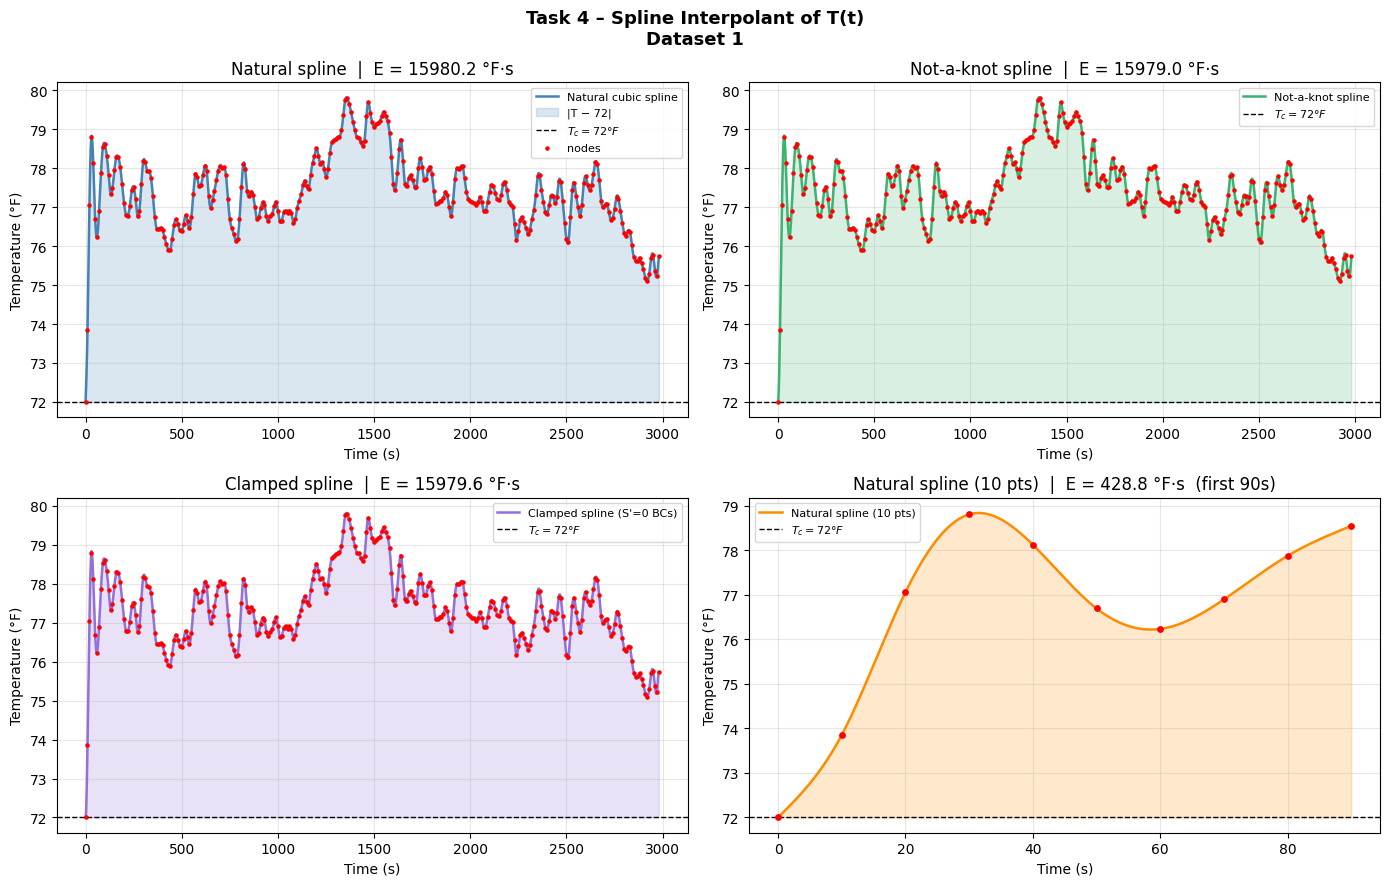


  Dataset 2
  E (Natural spline, all pts):       31924.63 °F·s
  E (Not-a-knot spline, all pts):    31922.77 °F·s
  E (Clamped spline, all pts):       31922.71 °F·s
  E (Natural spline, first 10 pts):  690.04 °F·s  [first 90s only]

  Max |dT/dt| (natural spline):  0.5819 °F/s
  Min T (natural spline):         58.35 °F
  Max T (natural spline):         72.00 °F


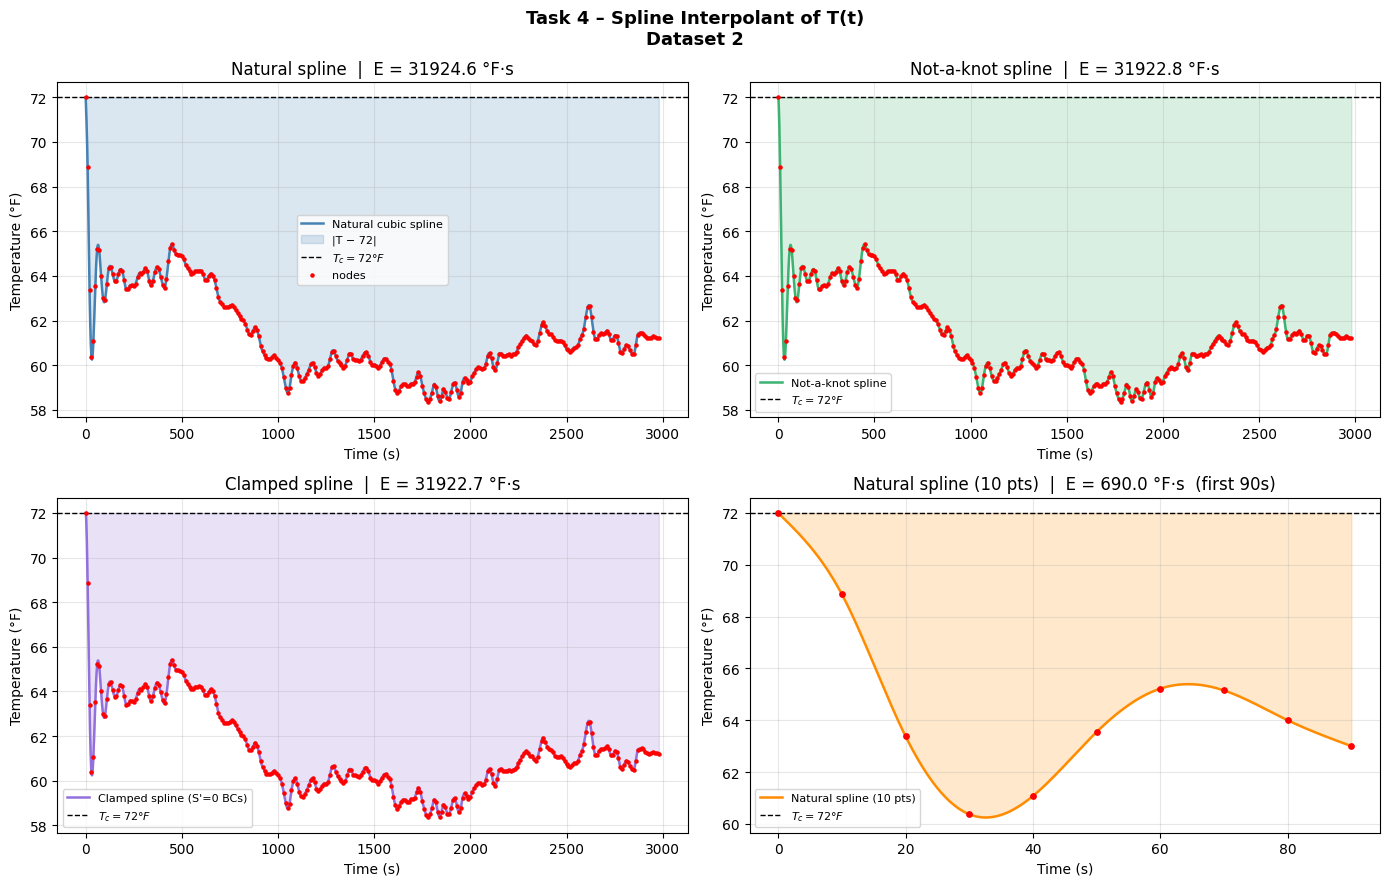


  Dataset 3
  E (Natural spline, all pts):       24921.17 °F·s
  E (Not-a-knot spline, all pts):    24919.29 °F·s
  E (Clamped spline, all pts):       24919.59 °F·s
  E (Natural spline, first 10 pts):  658.21 °F·s  [first 90s only]

  Max |dT/dt| (natural spline):  0.6181 °F/s
  Min T (natural spline):         50.02 °F
  Max T (natural spline):         83.63 °F


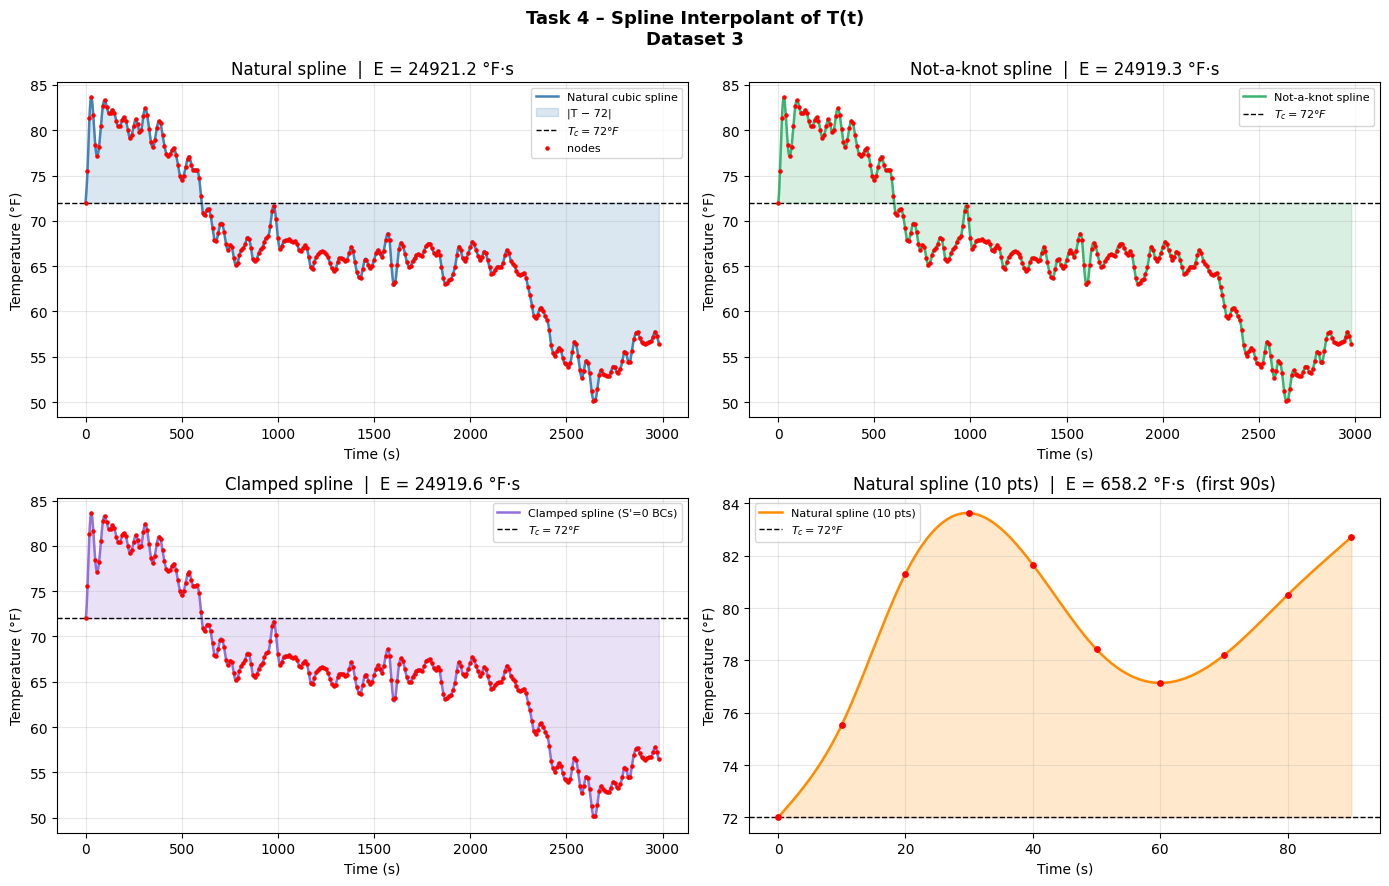

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import json
from pathlib import Path


def load_task3_definitions(notebook_path='task3.ipynb'):
    """Load Task 3 data and solver definitions without running its plots."""
    notebook = json.loads(Path(notebook_path).read_text(encoding='utf-8'))
    code = '\n'.join(
        ''.join(cell.get('source', []))
        for cell in notebook['cells']
        if cell.get('cell_type') == 'code'
    )
    code = code.split('\nfor theta_data, name in zip(datasets, dataset_names):')[0]
    namespace = {}
    exec(code, namespace)
    return namespace


_task3 = load_task3_definitions()
datasets      = _task3['datasets']
dataset_names = _task3['dataset_names']
solve_task3   = _task3['solve_task3']
alpha         = _task3['alpha']
k             = _task3['k']
dt_data       = _task3['dt_data']

# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────────────────────

Tc = 72.0   # comfort threshold (°F)
h  = 1.0    # ODE step size (same as teammate)


def integrate_exposure(t_fine, P_fine):
    """Trapezoid rule for ∫|P(t) − Tc| dt."""
    return np.trapz(np.abs(P_fine - Tc), t_fine)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN LOOP — one figure per dataset
# ─────────────────────────────────────────────────────────────────────────────

for theta_data, name in zip(datasets, dataset_names):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    # ── Obtain T(t) from Task 3 ODE solver ───────────────────────────────────
    t_solver, T_solver, _ = solve_task3(theta_data, h=h, alpha=alpha, k=k)

    # Subsample to measurement spacing (mirrors teammate's approach)
    step        = int(dt_data / h)
    t_nodes     = t_solver[::step]
    T_nodes     = T_solver[::step]
    t_fine      = np.linspace(t_nodes[0], t_nodes[-1], 2000)

    # ── METHOD 1: Natural cubic spline (all nodes) ───────────────────────────
    cs_natural  = CubicSpline(t_nodes, T_nodes, bc_type='natural')
    P_natural   = cs_natural(t_fine)
    E_natural   = integrate_exposure(t_fine, P_natural)

    # ── METHOD 2: Not-a-knot cubic spline (all nodes) ────────────────────────
    cs_nak      = CubicSpline(t_nodes, T_nodes, bc_type='not-a-knot')
    P_nak       = cs_nak(t_fine)
    E_nak       = integrate_exposure(t_fine, P_nak)

    # ── METHOD 3: Clamped cubic spline (zero-slope BCs) ──────────────────────
    # S'(t0) = 0, S'(tN) = 0 — reasonable when T is near steady-state at ends
    cs_clamped  = CubicSpline(t_nodes, T_nodes,
                              bc_type=((1, 0.0), (1, 0.0)))
    P_clamped   = cs_clamped(t_fine)
    E_clamped   = integrate_exposure(t_fine, P_clamped)

    # ── METHOD 4: Natural spline, first 10 nodes only ────────────────────────
    t10         = t_nodes[:10]
    T10         = T_nodes[:10]
    cs_10       = CubicSpline(t10, T10, bc_type='natural')
    t_fine_10   = np.linspace(t10[0], t10[-1], 500)
    P_10        = cs_10(t_fine_10)
    E_10        = integrate_exposure(t_fine_10, P_10)

    # ── Print results ─────────────────────────────────────────────────────────
    print(f"  E (Natural spline, all pts):       {E_natural:.2f} °F·s")
    print(f"  E (Not-a-knot spline, all pts):    {E_nak:.2f} °F·s")
    print(f"  E (Clamped spline, all pts):       {E_clamped:.2f} °F·s")
    print(f"  E (Natural spline, first 10 pts):  {E_10:.2f} °F·s  [first 90s only]")

    # ── Derivative info (for writeup) ─────────────────────────────────────────
    dT_natural  = cs_natural(t_fine, 1)   # first derivative
    print(f"\n  Max |dT/dt| (natural spline):  {np.max(np.abs(dT_natural)):.4f} °F/s")
    print(f"  Min T (natural spline):         {np.min(P_natural):.2f} °F")
    print(f"  Max T (natural spline):         {np.max(P_natural):.2f} °F")

    # ── 2×2 figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f'Task 4 – Spline Interpolant of T(t)\n{name}',
                 fontsize=13, fontweight='bold')

    # -- Panel 1: Natural spline (all pts) ------------------------------------
    ax = axes[0, 0]
    ax.plot(t_fine, P_natural, color='steelblue', lw=1.8,
            label='Natural cubic spline')
    ax.fill_between(t_fine, Tc, P_natural, alpha=0.2, color='steelblue',
                    label='|T − 72|')
    ax.axhline(Tc, color='k', linestyle='--', lw=1, label=r'$T_c = 72°F$')
    ax.scatter(t_nodes, T_nodes, color='red', s=5, zorder=5, label='nodes')
    ax.set_title(f'Natural spline  |  E = {E_natural:.1f} °F·s')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # -- Panel 2: Not-a-knot spline -------------------------------------------
    ax = axes[0, 1]
    ax.plot(t_fine, P_nak, color='mediumseagreen', lw=1.8,
            label='Not-a-knot spline')
    ax.fill_between(t_fine, Tc, P_nak, alpha=0.2, color='mediumseagreen')
    ax.axhline(Tc, color='k', linestyle='--', lw=1, label=r'$T_c = 72°F$')
    ax.scatter(t_nodes, T_nodes, color='red', s=5, zorder=5)
    ax.set_title(f'Not-a-knot spline  |  E = {E_nak:.1f} °F·s')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # -- Panel 3: Clamped spline ----------------------------------------------
    ax = axes[1, 0]
    ax.plot(t_fine, P_clamped, color='mediumpurple', lw=1.8,
            label="Clamped spline (S'=0 BCs)")
    ax.fill_between(t_fine, Tc, P_clamped, alpha=0.2, color='mediumpurple')
    ax.axhline(Tc, color='k', linestyle='--', lw=1, label=r'$T_c = 72°F$')
    ax.scatter(t_nodes, T_nodes, color='red', s=5, zorder=5)
    ax.set_title(f'Clamped spline  |  E = {E_clamped:.1f} °F·s')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # -- Panel 4: Natural spline, first 10 pts --------------------------------
    ax = axes[1, 1]
    ax.plot(t_fine_10, P_10, color='darkorange', lw=1.8,
            label='Natural spline (10 pts)')
    ax.fill_between(t_fine_10, Tc, P_10, alpha=0.2, color='darkorange')
    ax.axhline(Tc, color='k', linestyle='--', lw=1, label=r'$T_c = 72°F$')
    ax.scatter(t10, T10, color='red', s=15, zorder=5)
    ax.set_title(f'Natural spline (10 pts)  |  E = {E_10:.1f} °F·s  (first 90s)')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (°F)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── COMPARISON: spline vs teammate's piecewise Lagrange ──────────────────
    # (Uncomment if you want a direct side-by-side comparison plot)
    # fig2, ax2 = plt.subplots(figsize=(10, 5))
    # ax2.plot(t_fine, P_natural,  label=f'Natural spline   E={E_natural:.1f}',  color='steelblue')
    # ax2.plot(t_fine, P_pw_lagrange, label=f'Piecewise Lagrange E={E_pw:.1f}', color='darkorange', linestyle='--')
    # ax2.axhline(Tc, color='k', linestyle=':', lw=1)
    # ax2.set_title(f'Spline vs Piecewise Lagrange — {name}')
    # ax2.legend(); ax2.grid(True, alpha=0.3)
    # plt.tight_layout(); plt.show()